In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import ast
import math
from table_generator import aggregate_across_seeds, load_results_dataframe, flatten_config, diagnose_grouping_conflicts, get_best_runs_by_val_f1_macro

# Rebuild matplotlib font cache to detect newly installed fonts (CMU Serif)
fm._load_fontmanager(try_read_cache=False)
print("Font cache rebuilt. CMU Serif available:", "CMU Serif" in [f.name for f in fm.fontManager.ttflist])

Font cache rebuilt. CMU Serif available: True


In [3]:
csv_filename = "final_results_hyperparams.csv" 
df = pd.read_csv(csv_filename)
aggregated_df = aggregate_across_seeds(
    df,             # auto-detects
    metric_prefix="summary.",
    output_filename="aggregated_results.csv",
)

print(aggregated_df.shape)
aggregated_df.head()

/tmp/ipykernel_3388194/3967649953.py:2: DtypeWarning: Columns (63,69,70,89,98,107,108,109,110,117,123,154,162,164,170,171,179,181,185,192,195,198,201,224,225,229,233,234,235,239,240,242,243,244,245,246) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_filename)


▶ Using seed column: seed
▶ Found 57 metric columns with prefix 'summary.'
▶ Initial grouping candidates (after dropping bad cols): 186
▶ Final grouping columns (after nunique filter): 186
▶ Numeric metric columns kept: 56
▶ Dropped 1 all-NaN / non-numeric metric columns (e.g.): ['summary.checkpoint']
▶ Filtering: 26 groups removed (did not have exactly 3 seeds)
▶ Keeping: 42168 groups with exactly 3 seeds


/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:466: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_group_filtered = df_group.set_index(grouping_cols).loc[groups_with_3_seeds].reset_index()
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:466: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_group_filtered = df_group.set_index(grouping_cols).loc[groups_with_3_seeds].reset_index()
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:466: PerformanceWarning: DataFrame is highly fragmented.  This is 

▶ Aggregated shape: (42168, 354)
▶ Number of unique experiment configurations: 42168
▶ Saved aggregated results to: aggregated_results.csv
(42168, 354)


,loss._target_,loss.dataset_loss.task,loss.dataset_loss.loss_type,loss.dataset_loss.class_weights,loss.modules_losses.readout,loss.modules_losses.backbone,loss.modules_losses.feature_encoder,tags,test,model.compile,...,summary.val/f1_weighted_count,summary.val/loss,summary.val/loss_std,summary.val/loss_count,summary.val/precision,summary.val/precision_std,summary.val/precision_count,summary.val/recall,summary.val/recall_std,summary.val/recall_count
0,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.716205,0.199433,3,0.716134,0.009332,3,0.661818,0.016664,3
1,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.668792,0.111471,3,0.436156,0.160052,3,0.532727,0.056685,3
2,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,1.033895,0.065559,3,0.672486,0.039904,3,0.633333,0.019441,3
3,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.960883,0.213093,3,0.558465,0.186162,3,0.584242,0.075893,3
4,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,1.069859,0.300864,3,0.684009,0.007388,3,0.661212,0.033146,3


In [4]:
# ------------------------------------------------------------------
# Shared utilities and constants for all plots
# ------------------------------------------------------------------

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

def filter_complete_metrics(df, required_metrics):
    """Filter dataframe to only include rows where all required metrics have count == 3.
    
    This ensures fair comparison by only including runs where all 3 seeds
    have valid values for the specified metrics.
    
    Args:
        df: DataFrame with aggregated results (must have _count columns)
        required_metrics: List of metric column names (without _count suffix)
    
    Returns:
        Filtered DataFrame
    """
    mask = pd.Series(True, index=df.index)
    for metric in required_metrics:
        count_col = f"{metric}_count"
        if count_col in df.columns:
            mask &= (df[count_col] == 3)
    
    n_before = len(df)
    n_after = mask.sum()
    if n_before != n_after:
        print(f"▶ Filtered from {n_before} to {n_after} rows (requiring count=3 for: {required_metrics})")
    
    return df[mask].copy()

# ------------------------------------------------------------------
# Create consistent color mapping for all models
# ------------------------------------------------------------------

# Get all unique models from the aggregated data
model_col = "model.model_name"
df_temp = aggregated_df.copy()

# Decode serialized values for the model column
if model_col in df_temp.columns:
    df_temp[model_col] = df_temp[model_col].apply(_decode_val)

# Normalize model names to lowercase to avoid duplicates like "GATv4" vs "gatv4"
if model_col in df_temp.columns:
    df_temp[model_col] = df_temp[model_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Get all unique models found in data
models_in_data = set(df_temp[model_col].dropna().unique().tolist())
print(f"Found {len(models_in_data)} unique models in data: {sorted(models_in_data)}")

# Define CUSTOM MODEL ORDER:
# 1. MLP (baseline)
# 2. Classical GNNs: GIN, GCN, GATv2, SAGE
# 3. Big-graph GNN: SAGN
# 4. Omics GNNs: ChebNet, MLA-GNN (gatv4)
CANONICAL_MODEL_ORDER = ['mlp', 'gin', 'gcn', 'gatv2', 'sage', 'sagn', 'chebnet', 'gatv4']

# Display names mapping (internal name -> display name)
MODEL_DISPLAY_NAMES = {
    'mlp': 'MLP',
    'gin': 'GIN',
    'gcn': 'GCN',
    'gatv2': 'GATv2',
    'sage': 'SAGE',
    'sagn': 'SAGN',
    'chebnet': 'ChebNet',
    'gatv4': 'MLA-GNN',  # GATv4 displayed as MLA-GNN
}

def get_display_name(model):
    """Get the display name for a model."""
    return MODEL_DISPLAY_NAMES.get(model, model)

# Dataset display names mapping (internal name -> display name)
DATASET_DISPLAY_NAMES = {
    'motrpac': 'Heritage',
    'addneuromed': 'Addneuromed',
    'parkinsons': 'Parkinsons',
}

def get_dataset_display_name(dataset):
    """Get the display name for a dataset."""
    return DATASET_DISPLAY_NAMES.get(dataset, dataset.title())

# Filter to only models that exist in the data, maintaining order
all_models = [m for m in CANONICAL_MODEL_ORDER if m in models_in_data]
# Add any models in data not in our canonical order (shouldn't happen, but safety)
for m in sorted(models_in_data):
    if m not in all_models:
        all_models.append(m)

print(f"Ordered models: {[get_display_name(m) for m in all_models]}")

# Create a consistent color mapping for all models - each gets a distinct color
# Colors based on category:
# - MLP: blue
# - Classical GNNs (GIN, GCN, GATv2, SAGE): orange shades
# - SAGN: purple
# - Omics GNNs (ChebNet, MLA-GNN): green shades
shared_model_colors_dict = {
    'mlp': '#5B9BD5',      # Light blue - MLP baseline
    'gin': '#D62828',      # Dark red-orange - Classical GNN
    'gcn': '#E85D04',      # Orange - Classical GNN
    'gatv2': '#F48C06',    # Medium orange - Classical GNN
    'sage': '#FAA307',     # Light orange - Classical GNN
    'sagn': '#7B2CBF',     # Purple - Big-graph GNN
    'chebnet': '#2D6A4F',  # Dark green - Omics GNN
    'gatv4': '#52B788',    # Light green - Omics GNN (MLA-GNN)
}

# Baseline styling - distinct colors and styles for SVM and Elastic Net
# Both black with different line styles for distinction
BASELINE_STYLES = {
    'elastic_net': {'color': 'black', 'linestyle': '--', 'linewidth': 2.5, 'label': 'Elastic Net'},
    'svm': {'color': 'black', 'linestyle': ':', 'linewidth': 3, 'label': 'SVM'},
}

print(f"\nColor mapping:")
for model in all_models:
    print(f"  {get_display_name(model)}: {shared_model_colors_dict.get(model, 'NO COLOR')}")



Found 8 unique models in data: ['chebnet', 'gatv2', 'gatv4', 'gcn', 'gin', 'mlp', 'sage', 'sagn']
Ordered models: ['MLP', 'GIN', 'GCN', 'GATv2', 'SAGE', 'SAGN', 'ChebNet', 'MLA-GNN']

Color mapping:
  MLP: #5B9BD5
  GIN: #D62828
  GCN: #E85D04
  GATv2: #F48C06
  SAGE: #FAA307
  SAGN: #7B2CBF
  ChebNet: #2D6A4F
  MLA-GNN: #52B788


In [5]:
# ------------------------------------------------------------------
# Get best runs by val/f1_macro per dataset, method, and node_sample_ratio
# ------------------------------------------------------------------
best_runs_tables = get_best_runs_by_val_f1_macro(
    aggregated_df,
    metric_col="summary.best_val/f1_macro",
    datasets=["motrpac", "addneuromed", "parkinsons"]
)

# Display tables for each dataset (mean ± std)
for dataset_name, table in best_runs_tables.items():
    print(f"\n{'='*80}")
    print(f"Best val/f1_macro (mean ± std) for {dataset_name.upper()}")
    print(f"{'='*80}")
    print(table.to_string())
    print()



Best val/f1_macro (mean ± std) for MOTRPAC
dataset.loader.parameters.node_sample_ratio              0.3              0.5              0.8              1.0
dataset.loader.parameters.method                                                                               
correlation                                  0.6448 ± 0.0101  0.6619 ± 0.0054  0.6631 ± 0.0044  0.6614 ± 0.0046
distance_correlation                         0.6386 ± 0.0093  0.6488 ± 0.0171  0.6489 ± 0.0037  0.6595 ± 0.0132
random                                       0.6397 ± 0.0061  0.6409 ± 0.0135  0.6548 ± 0.0283  0.6607 ± 0.0184
variance                                     0.6529 ± 0.0319  0.6695 ± 0.0102  0.6752 ± 0.0179  0.6791 ± 0.0099


Best val/f1_macro (mean ± std) for ADDNEUROMED
dataset.loader.parameters.node_sample_ratio              0.3              0.5              0.8              1.0
dataset.loader.parameters.method                                                                               
correlation

/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:753: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6448 ± 0.0101' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[idx, col] = f"{mean_val:.4f} ± {std_val:.4f}"
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:753: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6619 ± 0.0054' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[idx, col] = f"{mean_val:.4f} ± {std_val:.4f}"
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:753: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6631 ± 0.0044' has dtype incompatible with float64, please explicitly 

▶ Filtered from 42168 to 40260 rows (requiring count=3 for: ['summary.best_val/f1_macro', 'summary.best_test/f1_macro'])


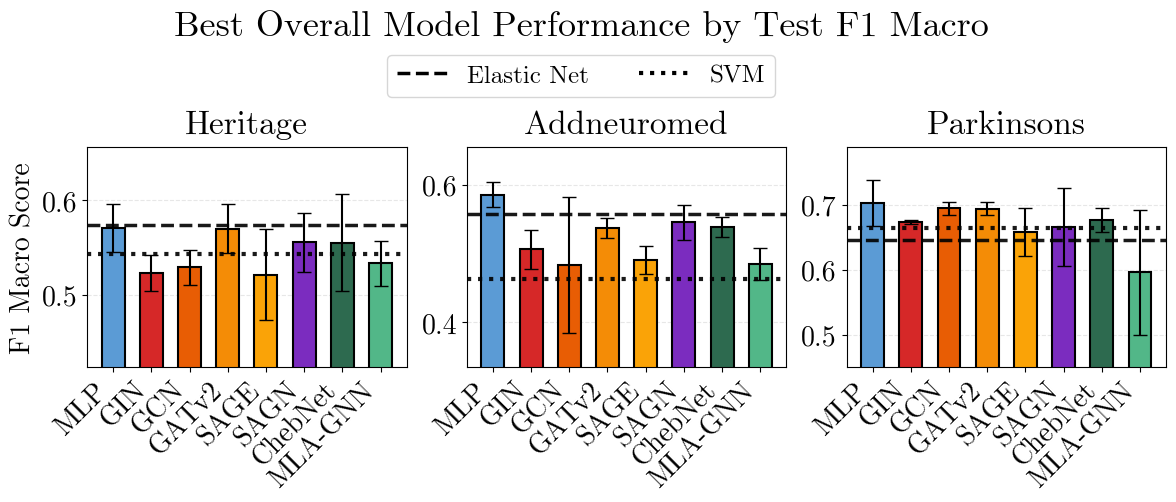


Best Test F1 Macro by Model and Dataset (selected by Val F1 Macro):

MLP:
  motrpac: 0.5707 ± 0.0251
  addneuromed: 0.5858 ± 0.0187
  parkinsons: 0.7030 ± 0.0357

GIN:
  motrpac: 0.5231 ± 0.0188
  addneuromed: 0.5065 ± 0.0283
  parkinsons: 0.6736 ± 0.0034

GCN:
  motrpac: 0.5295 ± 0.0184
  addneuromed: 0.4838 ± 0.0991
  parkinsons: 0.6948 ± 0.0099

GATv2:
  motrpac: 0.5702 ± 0.0261
  addneuromed: 0.5373 ± 0.0144
  parkinsons: 0.6941 ± 0.0094

SAGE:
  motrpac: 0.5216 ± 0.0481
  addneuromed: 0.4909 ± 0.0203
  parkinsons: 0.6581 ± 0.0375

SAGN:
  motrpac: 0.5556 ± 0.0310
  addneuromed: 0.5452 ± 0.0254
  parkinsons: 0.6658 ± 0.0607

ChebNet:
  motrpac: 0.5554 ± 0.0508
  addneuromed: 0.5386 ± 0.0140
  parkinsons: 0.6762 ± 0.0186

MLA-GNN:
  motrpac: 0.5333 ± 0.0241
  addneuromed: 0.4849 ± 0.0231
  parkinsons: 0.5962 ± 0.0965


In [6]:
# ------------------------------------------------------------------
# Plot: Best Overall Model Performance by Test F1 Macro
# Selection: Best model by val/f1_macro
# Display: Test F1 Macro (mean ± std) for the selected runs
# ------------------------------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Column definitions
selection_metric_col = "summary.best_val/f1_macro"  # Use VAL F1 to select best runs
plot_metric_col = "summary.best_test/f1_macro"  # Plot TEST F1 for selected runs
plot_metric_std_col = f"{plot_metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
model_col = "model.model_name"

# Load and prepare data
df_plot = aggregated_df.copy()

# Filter for complete metrics (all 3 seeds must have val f1_macro and test f1_macro)
df_plot = filter_complete_metrics(df_plot, [selection_metric_col, plot_metric_col])

# Decode serialized values for the grouping columns
for col in [data_name_col, model_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Normalize model names to lowercase to avoid duplicates
df_plot[model_col] = df_plot[model_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Ensure metrics are numeric
df_plot[selection_metric_col] = pd.to_numeric(df_plot[selection_metric_col], errors="coerce")
df_plot[plot_metric_col] = pd.to_numeric(df_plot[plot_metric_col], errors="coerce")
df_plot[plot_metric_std_col] = pd.to_numeric(df_plot[plot_metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, model_col, selection_metric_col, plot_metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models using CANONICAL_MODEL_ORDER
models_in_data = set(df_plot[model_col].dropna().unique().tolist())
all_models = [m for m in CANONICAL_MODEL_ORDER if m in models_in_data]
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order

# For each model-dataset combination, find the best run by VAL F1, then get TEST F1
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        # Filter for this model-dataset combination
        subset = df_plot[
            (df_plot[model_col] == model) &
            (df_plot[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best run by VAL F1 Macro
            best_idx = subset[selection_metric_col].idxmax()
            # Extract TEST F1 Macro from that same run
            plot_data[model][dataset] = {
                'mean': subset.loc[best_idx, plot_metric_col],
                'std': subset.loc[best_idx, plot_metric_std_col]
            }
        else:
            plot_data[model][dataset] = {'mean': np.nan, 'std': np.nan}

# Use the shared color mapping created in the previous cell
# This ensures consistent colors across all plots
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")
method_colors_dict = shared_model_colors_dict  # Use the shared color mapping

# Calculate min and max y-values per dataset (each subplot gets its own y-axis)
dataset_ylims = {}
for dataset in datasets:
    vals_with_std = []
    for model in all_models:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            std_val = data['std'] if not np.isnan(data['std']) else 0
            vals_with_std.append(data['mean'] - std_val)
            vals_with_std.append(data['mean'] + std_val)
    if vals_with_std:
        dataset_ylims[dataset] = (min(vals_with_std) - 0.05, max(vals_with_std) + 0.05)
    else:
        dataset_ylims[dataset] = (0, 1)

# Create the subplot grid: 1 row x 3 columns (datasets), all models together
fig, axes = plt.subplots(1, len(datasets), figsize=(12, 5))
fig.suptitle('Best Overall Model Performance by Test F1 Macro', #\n(Selected by Val F1 Macro)', 
             fontsize=26, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Collect data for all models for this dataset
    means = []
    stds = []
    labels = []
    colors = []
    
    for model in all_models:
        data = plot_data[model][dataset]
        mean_val = data['mean']
        std_val = data['std']
        
        if not np.isnan(mean_val):
            means.append(mean_val)
            stds.append(std_val)
            labels.append(get_display_name(model))
            colors.append(method_colors_dict[model])
    
    # Create positions for bars
    if len(means) > 0:
        x_positions = np.arange(len(means))
        bar_width = 0.6  # Fixed bar width
        
        # Create grouped bars for all models
        bars = ax.bar(
            x_positions,
            means,
            yerr=stds,
            width=bar_width,
            capsize=5,
            color=colors,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Add baseline horizontal lines (F1 Macro scores)
        baselines = {
            'parkinsons': {
                'elastic_net': 0.64518,
                'svm': 0.66422
            },
            'motrpac': {
                'elastic_net': 0.57419,
                'svm': 0.54287
            },
            'addneuromed': {
                'elastic_net': 0.55762,
                'svm': 0.46252
            }
        }
        
        # Plot baseline lines for this dataset with distinct styling
        if dataset in baselines:
            for baseline_name, baseline_value in baselines[dataset].items():
                style = BASELINE_STYLES[baseline_name]
                ax.axhline(
                    y=baseline_value,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth'],
                    alpha=0.9,
                    label=style['label']
                )
        
        # Customize subplot
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
    else:
        # No data for this dataset
        ax.set_xticks([])
    
    ax.tick_params(axis='both', labelsize=20)
    ax.set_title(get_dataset_display_name(dataset), fontsize=24, fontweight='bold', pad=10)
    # Only show y-axis label on leftmost subplot
    if j == 0:
        ax.set_ylabel('F1 Macro Score', fontsize=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(dataset_ylims[dataset])

# Add legend at top (like the readout legend)
from matplotlib.lines import Line2D
baseline_handles = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.5, label='Elastic Net'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=3, label='SVM')
]
fig.legend(handles=baseline_handles, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
           ncol=2, fontsize=18, frameon=True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('best_overall_test_f1_macro.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print the values for reference
print("\nBest Test F1 Macro by Model and Dataset (selected by Val F1 Macro):")
print("=" * 80)
for model in all_models:
    print(f"\n{get_display_name(model)}:")
    for dataset in datasets:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            print(f"  {dataset}: {data['mean']:.4f} ± {data['std']:.4f}")
        else:
            print(f"  {dataset}: No data")


▶ Filtered from 42168 to 40260 rows (requiring count=3 for: ['summary.best_val/f1_macro', 'summary.best_test/f1_macro'])


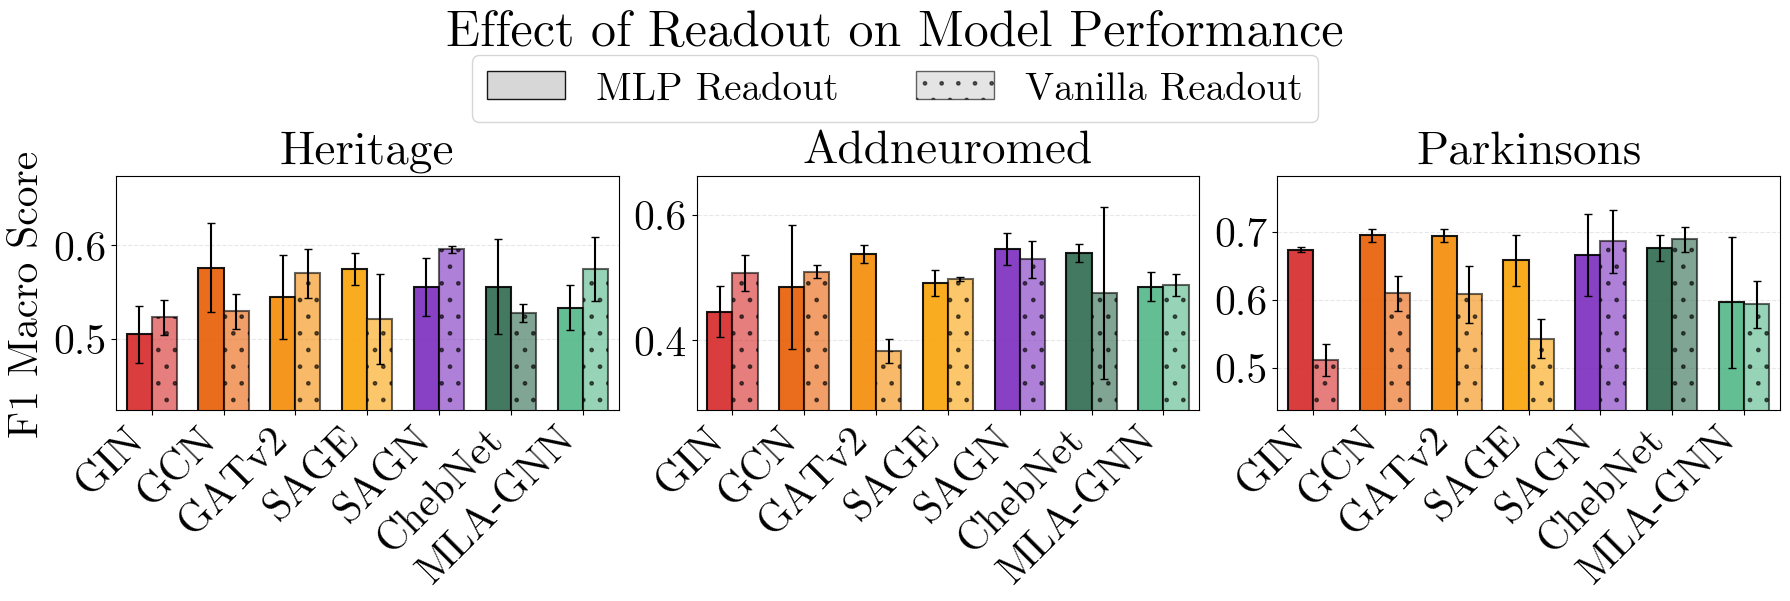


Effect of Readout on Model Performance:

GIN:
  motrpac:
    With Readout: Test F1=0.5046 ± 0.0307 (Val F1=0.6460)
    Without Readout: Test F1=0.5231 ± 0.0188 (Val F1=0.6620)
  addneuromed:
    With Readout: Test F1=0.4444 ± 0.0408 (Val F1=0.5417)
    Without Readout: Test F1=0.5065 ± 0.0283 (Val F1=0.5881)
  parkinsons:
    With Readout: Test F1=0.6736 ± 0.0034 (Val F1=0.8135)
    Without Readout: Test F1=0.5111 ± 0.0236 (Val F1=0.7561)

GCN:
  motrpac:
    With Readout: Test F1=0.5762 ± 0.0479 (Val F1=0.6580)
    Without Readout: Test F1=0.5295 ± 0.0184 (Val F1=0.6629)
  addneuromed:
    With Readout: Test F1=0.4838 ± 0.0991 (Val F1=0.5948)
    Without Readout: Test F1=0.5087 ± 0.0103 (Val F1=0.5226)
  parkinsons:
    With Readout: Test F1=0.6948 ± 0.0099 (Val F1=0.8068)
    Without Readout: Test F1=0.6097 ± 0.0257 (Val F1=0.7199)

GATv2:
  motrpac:
    With Readout: Test F1=0.5445 ± 0.0450 (Val F1=0.6412)
    Without Readout: Test F1=0.5702 ± 0.0261 (Val F1=0.6605)
  addneuromed:


In [24]:
# ------------------------------------------------------------------
# Plot: Effect of Readout on Model Performance (Test F1 Macro)
# Selection: Best model by val/f1_macro for each readout type
# Display: Test F1 Macro (mean ± std) for the selected runs
# ------------------------------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Column definitions
selection_metric_col = "summary.best_val/f1_macro"  # Use VAL F1 to select best runs
plot_metric_col = "summary.best_test/f1_macro"  # Plot TEST F1 for selected runs
plot_metric_std_col = f"{plot_metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
model_col = "model.model_name"
readout_col = "model.readout.readout_name"

# Load and prepare data
df_plot = aggregated_df.copy()

# Filter for complete metrics (all 3 seeds must have val f1_macro and test f1_macro)
df_plot = filter_complete_metrics(df_plot, [selection_metric_col, plot_metric_col])

# Decode serialized values for the grouping columns
for col in [data_name_col, model_col, readout_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Normalize model names to lowercase to avoid duplicates
df_plot[model_col] = df_plot[model_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Ensure metrics are numeric
df_plot[selection_metric_col] = pd.to_numeric(df_plot[selection_metric_col], errors="coerce")
df_plot[plot_metric_col] = pd.to_numeric(df_plot[plot_metric_col], errors="coerce")
df_plot[plot_metric_std_col] = pd.to_numeric(df_plot[plot_metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, model_col, readout_col, selection_metric_col, plot_metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models and datasets
# Exclude MLP since it doesn't have a readout option (no comparison to show)
models_in_data = set(df_plot[model_col].dropna().unique().tolist())
all_models = [m for m in CANONICAL_MODEL_ORDER if m in models_in_data and m != 'mlp']
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order
readout_types = ["OmicsReadOut", "NoReadOut"]  # With readout, Without readout

# For each model-dataset-readout combination, find the best run by VAL F1, then get TEST F1
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        plot_data[model][dataset] = {}
        for readout in readout_types:
            # Filter for this model-dataset-readout combination
            subset = df_plot[
                (df_plot[model_col] == model) &
                (df_plot[data_name_col] == dataset) &
                (df_plot[readout_col] == readout)
            ]
            
            if len(subset) > 0:
                # Find the best run by VAL F1 Macro
                best_idx = subset[selection_metric_col].idxmax()
                # Extract TEST F1 Macro from that same run
                plot_data[model][dataset][readout] = {
                    'mean': subset.loc[best_idx, plot_metric_col],
                    'std': subset.loc[best_idx, plot_metric_std_col],
                    'val_f1': subset.loc[best_idx, selection_metric_col]
                }
            else:
                plot_data[model][dataset][readout] = {'mean': np.nan, 'std': np.nan, 'val_f1': np.nan}

# Use the shared color mapping
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")

# Calculate min and max y-values per dataset (each subplot gets its own y-axis)
dataset_ylims = {}
for dataset in datasets:
    vals_with_std = []
    for model in all_models:
        for readout in readout_types:
            data = plot_data[model][dataset][readout]
            if not np.isnan(data['mean']):
                std_val = data['std'] if not np.isnan(data['std']) else 0
                vals_with_std.append(data['mean'] - std_val)
                vals_with_std.append(data['mean'] + std_val)
    if vals_with_std:
        dataset_ylims[dataset] = (min(vals_with_std) - 0.05, max(vals_with_std) + 0.05)
    else:
        dataset_ylims[dataset] = (0, 1)

# Create the subplot grid: 1 row x 3 columns (datasets)
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 6))
fig.suptitle('Effect of Readout on Model Performance', #\n(Selected by Val F1 Macro)', 
             fontsize=36, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Readout labels and hatching for visual distinction
readout_labels = {"OmicsReadOut": "With Readout", "NoReadOut": "Without Readout"}
readout_hatches = {"OmicsReadOut": "", "NoReadOut": "."}

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Create positions for grouped bars
    x_positions = np.arange(len(all_models))
    bar_width = 0.35
    
    # Plot bars for each model - handle models with/without readout options
    for m_idx, model in enumerate(all_models):
        # Check which readout types have data for this model
        has_with_readout = not np.isnan(plot_data[model][dataset]["OmicsReadOut"]['mean'])
        has_without_readout = not np.isnan(plot_data[model][dataset]["NoReadOut"]['mean'])
        
        if has_with_readout and has_without_readout:
            # Model has both readout options - show two bars
            for r_idx, readout in enumerate(readout_types):
                data = plot_data[model][dataset][readout]
                offset = (r_idx - 0.5) * bar_width
                ax.bar(
                    x_positions[m_idx] + offset,
                    data['mean'],
                    yerr=data['std'] if not np.isnan(data['std']) else 0,
                    width=bar_width,
                    capsize=3,
                    color=shared_model_colors_dict[model],
                    edgecolor='black',
                    linewidth=1.5,
                    hatch=readout_hatches[readout],
                    alpha=0.9 if readout == "OmicsReadOut" else 0.6
                )
        elif has_with_readout or has_without_readout:
            # Model has only one readout option (e.g., MLP) - show single centered bar
            readout = "OmicsReadOut" if has_with_readout else "NoReadOut"
            data = plot_data[model][dataset][readout]
            ax.bar(
                x_positions[m_idx],
                data['mean'],
                yerr=data['std'] if not np.isnan(data['std']) else 0,
                width=bar_width * 1.5,  # Slightly wider for single bar
                capsize=3,
                color=shared_model_colors_dict[model],
                edgecolor='black',
                linewidth=1.5,
                hatch=readout_hatches[readout],
                alpha=0.9 if readout == "OmicsReadOut" else 0.6
            )
    
    # Customize subplot
    ax.set_xticks(x_positions)
    ax.set_xticklabels([get_display_name(m) for m in all_models], rotation=45, ha='right', fontsize=30)
    ax.tick_params(axis='both', labelsize=30)
    ax.set_title(get_dataset_display_name(dataset), fontsize=34, fontweight='bold', pad=10)
    # Only show y-axis label on leftmost subplot
    if j == 0:
        ax.set_ylabel('F1 Macro Score', fontsize=30)
    ax.set_xlim(-0.5, len(all_models) - 0.5)  # Adjust x-axis limits after removing MLP
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(dataset_ylims[dataset])

# Add legend at top
handles, labels = axes[0, 0].get_legend_handles_labels()
# Create custom legend handles for readout types
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='lightgray', edgecolor='black', hatch='', alpha=0.9, label='MLP Readout'),
    Patch(facecolor='lightgray', edgecolor='black', hatch='.', alpha=0.6, label='Vanilla Readout')
]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.95), 
           ncol=2, fontsize=28, frameon=True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('effect_of_readout_test_f1_macro.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print the values for reference
print("\nEffect of Readout on Model Performance:")
print("=" * 80)
for model in all_models:
    print(f"\n{get_display_name(model)}:")
    for dataset in datasets:
        print(f"  {dataset}:")
        for readout in readout_types:
            data = plot_data[model][dataset][readout]
            if not np.isnan(data['mean']):
                print(f"    {readout_labels[readout]}: Test F1={data['mean']:.4f} ± {data['std']:.4f} (Val F1={data['val_f1']:.4f})")
            else:
                print(f"    {readout_labels[readout]}: No data")


▶ Filtered from 42168 to 40260 rows (requiring count=3 for: ['summary.best_val/f1_macro', 'summary.best_test/accuracy'])


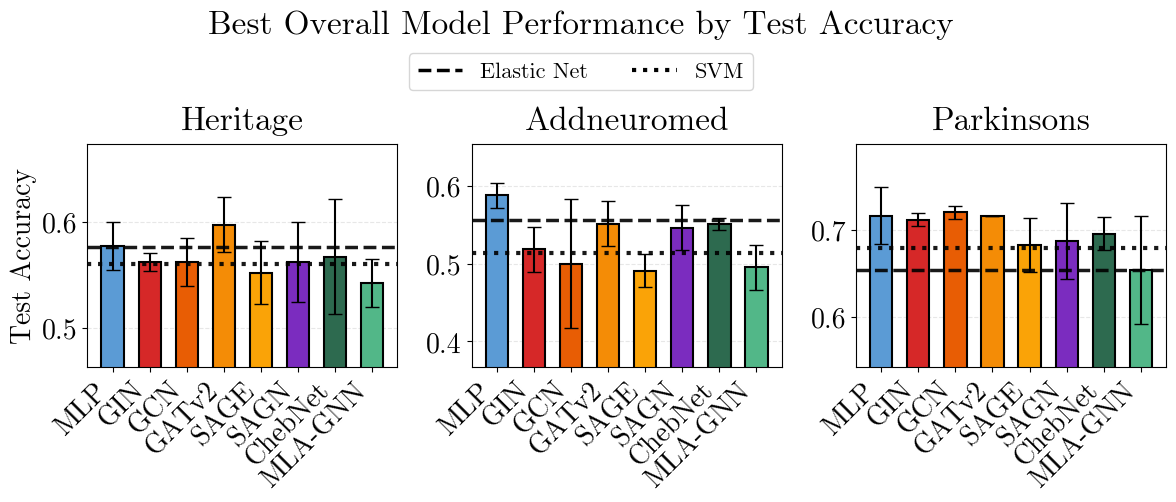


Best Performance by Model and Dataset (Test Accuracy, selected by F1 Macro):

MLP:
  motrpac: 0.5771 ± 0.0228
  addneuromed: 0.5880 ± 0.0160
  parkinsons: 0.7160 ± 0.0327

GIN:
  motrpac: 0.5622 ± 0.0086
  addneuromed: 0.5185 ± 0.0289
  parkinsons: 0.7119 ± 0.0071

GCN:
  motrpac: 0.5622 ± 0.0228
  addneuromed: 0.5000 ± 0.0833
  parkinsons: 0.7202 ± 0.0071

GATv2:
  motrpac: 0.5970 ± 0.0259
  addneuromed: 0.5509 ± 0.0289
  parkinsons: 0.7160 ± 0.0000

SAGE:
  motrpac: 0.5522 ± 0.0299
  addneuromed: 0.4907 ± 0.0212
  parkinsons: 0.6831 ± 0.0311

SAGN:
  motrpac: 0.5622 ± 0.0376
  addneuromed: 0.5463 ± 0.0289
  parkinsons: 0.6872 ± 0.0434

ChebNet:
  motrpac: 0.5672 ± 0.0538
  addneuromed: 0.5509 ± 0.0080
  parkinsons: 0.6955 ± 0.0189

MLA-GNN:
  motrpac: 0.5423 ± 0.0228
  addneuromed: 0.4954 ± 0.0289
  parkinsons: 0.6543 ± 0.0617


In [8]:
# ------------------------------------------------------------------
# Plot: Best Overall Model Performance by Test Accuracy
# Selection: Best model by val/f1_macro
# Display: Test Accuracy (mean ± std) for the selected runs
# ------------------------------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Column definitions
selection_metric_col = "summary.best_val/f1_macro"  # Use VAL F1 to select best runs
plot_metric_col = "summary.best_test/accuracy"  # Plot TEST accuracy for selected runs
plot_metric_std_col = f"{plot_metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
model_col = "model.model_name"

# Load and prepare data
df_plot = aggregated_df.copy()

# Filter for complete metrics (all 3 seeds must have val f1_macro and test accuracy)
df_plot = filter_complete_metrics(df_plot, [selection_metric_col, plot_metric_col])

# Decode serialized values for the grouping columns
for col in [data_name_col, model_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Normalize model names to lowercase to avoid duplicates
df_plot[model_col] = df_plot[model_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Ensure metrics are numeric
df_plot[selection_metric_col] = pd.to_numeric(df_plot[selection_metric_col], errors="coerce")
df_plot[plot_metric_col] = pd.to_numeric(df_plot[plot_metric_col], errors="coerce")
df_plot[plot_metric_std_col] = pd.to_numeric(df_plot[plot_metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, model_col, selection_metric_col, plot_metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models using CANONICAL_MODEL_ORDER
models_in_data = set(df_plot[model_col].dropna().unique().tolist())
all_models = [m for m in CANONICAL_MODEL_ORDER if m in models_in_data]
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order

# For each model-dataset combination, find the best run by VAL F1, then get TEST Accuracy
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        # Filter for this model-dataset combination
        subset = df_plot[
            (df_plot[model_col] == model) &
            (df_plot[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best run by VAL F1 Macro
            best_idx = subset[selection_metric_col].idxmax()
            # Extract TEST Accuracy from that same run
            plot_data[model][dataset] = {
                'mean': subset.loc[best_idx, plot_metric_col],
                'std': subset.loc[best_idx, plot_metric_std_col]
            }
        else:
            plot_data[model][dataset] = {'mean': np.nan, 'std': np.nan}

# Use the shared color mapping created earlier
# This ensures consistent colors across all plots
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")
method_colors_dict = shared_model_colors_dict  # Use the shared color mapping

# Calculate min and max y-values per dataset (each subplot gets its own y-axis)
dataset_ylims = {}
for dataset in datasets:
    vals_with_std = []
    for model in all_models:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            std_val = data['std'] if not np.isnan(data['std']) else 0
            vals_with_std.append(data['mean'] - std_val)
            vals_with_std.append(data['mean'] + std_val)
    if vals_with_std:
        dataset_ylims[dataset] = (min(vals_with_std) - 0.05, max(vals_with_std) + 0.05)
    else:
        dataset_ylims[dataset] = (0, 1)

# Create the subplot grid: 1 row x 3 columns (datasets), all models together
fig, axes = plt.subplots(1, len(datasets), figsize=(12, 5))
fig.suptitle('Best Overall Model Performance by Test Accuracy', #\n(Selected by Val F1 Macro)', 
             fontsize=24, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Collect data for all models for this dataset
    means = []
    stds = []
    labels = []
    colors = []
    
    for model in all_models:
        data = plot_data[model][dataset]
        mean_val = data['mean']
        std_val = data['std']
        
        if not np.isnan(mean_val):
            means.append(mean_val)
            stds.append(std_val)
            labels.append(get_display_name(model))
            colors.append(method_colors_dict[model])
    
    # Create positions for bars
    if len(means) > 0:
        x_positions = np.arange(len(means))
        bar_width = 0.6  # Fixed bar width
        
        # Create grouped bars for all models
        bars = ax.bar(
            x_positions,
            means,
            yerr=stds,
            width=bar_width,
            capsize=5,
            color=colors,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Add baseline horizontal lines (Test Accuracy scores)
        baselines = {
            'parkinsons': {
                'elastic_net': 0.65432,
                'svm': 0.67901
            },
            'motrpac': {
                'elastic_net': 0.57576,
                'svm': 0.56061
            },
            'addneuromed': {
                'elastic_net': 0.55556,
                'svm': 0.51389
            }
        }
        
        # Plot baseline lines for this dataset with distinct styling
        if dataset in baselines:
            for baseline_name, baseline_value in baselines[dataset].items():
                style = BASELINE_STYLES[baseline_name]
                ax.axhline(
                    y=baseline_value,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth'],
                    alpha=0.9,
                    label=style['label']
                )
        
        # Customize subplot
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
    else:
        # No data for this dataset
        ax.set_xticks([])
    
    ax.tick_params(axis='both', labelsize=20)
    ax.set_title(get_dataset_display_name(dataset), fontsize=24, fontweight='bold', pad=10)
    # Only show y-axis label on leftmost subplot
    if j == 0:
        ax.set_ylabel('Test Accuracy', fontsize=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(dataset_ylims[dataset])

# Add legend at top (like the readout legend)
from matplotlib.lines import Line2D
baseline_handles = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.5, label='Elastic Net'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=3, label='SVM')
]
fig.legend(handles=baseline_handles, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
           ncol=2, fontsize=16, frameon=True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('best_overall_test_accuracy.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print the values for reference
print("\nBest Performance by Model and Dataset (Test Accuracy, selected by F1 Macro):")
print("=" * 80)
for model in all_models:
    print(f"\n{get_display_name(model)}:")
    for dataset in datasets:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            print(f"  {dataset}: {data['mean']:.4f} ± {data['std']:.4f}")
        else:
            print(f"  {dataset}: No data")


In [9]:
# ------------------------------------------------------------------
# Export best model results to JSON
# Selection: Best model by val/f1_macro for each model-dataset combination
# Output: Test F1 Macro and Test Accuracy for selected runs
# ------------------------------------------------------------------
import json

# Column definitions
selection_metric_col = "summary.best_val/f1_macro"
test_f1_col = "summary.best_test/f1_macro"
test_f1_std_col = f"{test_f1_col}_std"
test_acc_col = "summary.best_test/accuracy"
test_acc_std_col = f"{test_acc_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
model_col = "model.model_name"

# Load and prepare data
df_json = aggregated_df.copy()

# Filter for complete metrics (all 3 seeds must have val f1_macro, test f1_macro, and test accuracy)
df_json = filter_complete_metrics(df_json, [selection_metric_col, test_f1_col, test_acc_col])

# Decode serialized values
for col in [data_name_col, model_col]:
    if col in df_json.columns:
        df_json[col] = df_json[col].apply(_decode_val)

# Normalize model names to lowercase
df_json[model_col] = df_json[model_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Ensure metrics are numeric
for col in [selection_metric_col, test_f1_col, test_f1_std_col, test_acc_col, test_acc_std_col]:
    df_json[col] = pd.to_numeric(df_json[col], errors="coerce")

# Filter to valid data and the three datasets
df_json = df_json.dropna(subset=[data_name_col, model_col, selection_metric_col, test_f1_col, test_acc_col])
df_json = df_json[df_json[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Models to include (internal name -> display name)
models_to_include = {
    'mlp': 'MLP',
    'gatv4': 'MLA-GNN',
    'gatv2': 'GATv2',
    'gin': 'GIN',
    'gcn': 'GCN',
    'sage': 'GraphSAGE',
    'sagn': 'SAGN',
}

datasets = ["motrpac", "addneuromed", "parkinsons"]

# Hardcoded baseline results (these don't have std since they're single runs)
baselines_f1 = {
    'parkinsons': {'Elastic Net': 0.64518, 'SVM': 0.66422},
    'motrpac': {'Elastic Net': 0.57419, 'SVM': 0.54287},
    'addneuromed': {'Elastic Net': 0.55762, 'SVM': 0.46252}
}

baselines_acc = {
    'parkinsons': {'Elastic Net': 0.65432, 'SVM': 0.67901},
    'motrpac': {'Elastic Net': 0.57576, 'SVM': 0.56061},
    'addneuromed': {'Elastic Net': 0.55556, 'SVM': 0.51389}
}

# Build the results dictionary
results = {}

for dataset in datasets:
    results[dataset] = {}
    
    # Add GNN/MLP models
    for internal_name, display_name in models_to_include.items():
        subset = df_json[
            (df_json[model_col] == internal_name) &
            (df_json[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best run by VAL F1 Macro
            best_idx = subset[selection_metric_col].idxmax()
            
            results[dataset][display_name] = {
                'test_f1_macro': {
                    'mean': round(subset.loc[best_idx, test_f1_col], 5),
                    'std': round(subset.loc[best_idx, test_f1_std_col], 5)
                },
                'test_accuracy': {
                    'mean': round(subset.loc[best_idx, test_acc_col], 5),
                    'std': round(subset.loc[best_idx, test_acc_std_col], 5)
                }
            }
        else:
            results[dataset][display_name] = None
    
    # Add baseline models (no std available)
    for baseline_name in ['Elastic Net', 'SVM']:
        results[dataset][baseline_name] = {
            'test_f1_macro': {
                'mean': baselines_f1[dataset][baseline_name],
                'std': None  # No std available for baselines
            },
            'test_accuracy': {
                'mean': baselines_acc[dataset][baseline_name],
                'std': None  # No std available for baselines
            }
        }

# Save to JSON file
output_filename = "best_model_results.json"
with open(output_filename, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {output_filename}")
print("\n" + "=" * 80)
print("Best Model Results (Selected by Val F1 Macro)")
print("=" * 80)

for dataset in datasets:
    print(f"\n{dataset.upper()}:")
    print("-" * 60)
    for model_name in list(models_to_include.values()) + ['Elastic Net', 'SVM']:
        data = results[dataset].get(model_name)
        if data:
            f1_str = f"{data['test_f1_macro']['mean']:.4f}"
            if data['test_f1_macro']['std']:
                f1_str += f" ± {data['test_f1_macro']['std']:.4f}"
            
            acc_str = f"{data['test_accuracy']['mean']:.4f}"
            if data['test_accuracy']['std']:
                acc_str += f" ± {data['test_accuracy']['std']:.4f}"
            
            print(f"  {model_name:12s}: F1={f1_str:20s} Acc={acc_str}")
        else:
            print(f"  {model_name:12s}: No data")


▶ Filtered from 42168 to 40260 rows (requiring count=3 for: ['summary.best_val/f1_macro', 'summary.best_test/f1_macro', 'summary.best_test/accuracy'])
Results saved to best_model_results.json

Best Model Results (Selected by Val F1 Macro)

MOTRPAC:
------------------------------------------------------------
  MLP         : F1=0.5707 ± 0.0251      Acc=0.5771 ± 0.0228
  MLA-GNN     : F1=0.5333 ± 0.0241      Acc=0.5423 ± 0.0228
  GATv2       : F1=0.5702 ± 0.0261      Acc=0.5970 ± 0.0259
  GIN         : F1=0.5231 ± 0.0188      Acc=0.5622 ± 0.0086
  GCN         : F1=0.5295 ± 0.0184      Acc=0.5622 ± 0.0228
  GraphSAGE   : F1=0.5216 ± 0.0481      Acc=0.5522 ± 0.0299
  SAGN        : F1=0.5556 ± 0.0310      Acc=0.5622 ± 0.0376
  Elastic Net : F1=0.5742               Acc=0.5758
  SVM         : F1=0.5429               Acc=0.5606

ADDNEUROMED:
------------------------------------------------------------
  MLP         : F1=0.5858 ± 0.0187      Acc=0.5880 ± 0.0160
  MLA-GNN     : F1=0.4849 ± 0.023

▶ Filtered from 42168 to 40260 rows (requiring count=3 for: ['summary.best_val/f1_macro', 'summary.best_test/f1_macro'])
Best Overall Selections (matching the first plot):
  ChebNet    + addneuromed  -> method=variance, ratio=0.5
  ChebNet    + motrpac      -> method=variance, ratio=0.5
  ChebNet    + parkinsons   -> method=distance_correlation, ratio=0.8
  GATv2      + addneuromed  -> method=variance, ratio=0.5
  GATv2      + motrpac      -> method=correlation, ratio=0.8
  GATv2      + parkinsons   -> method=distance_correlation, ratio=0.3
  MLA-GNN    + addneuromed  -> method=variance, ratio=0.5
  MLA-GNN    + motrpac      -> method=distance_correlation, ratio=1.0
  MLA-GNN    + parkinsons   -> method=random, ratio=0.3
  GCN        + addneuromed  -> method=variance, ratio=0.8
  GCN        + motrpac      -> method=correlation, ratio=0.8
  GCN        + parkinsons   -> method=distance_correlation, ratio=0.3
  GIN        + addneuromed  -> method=distance_correlation, ratio=0.8
  GIN     

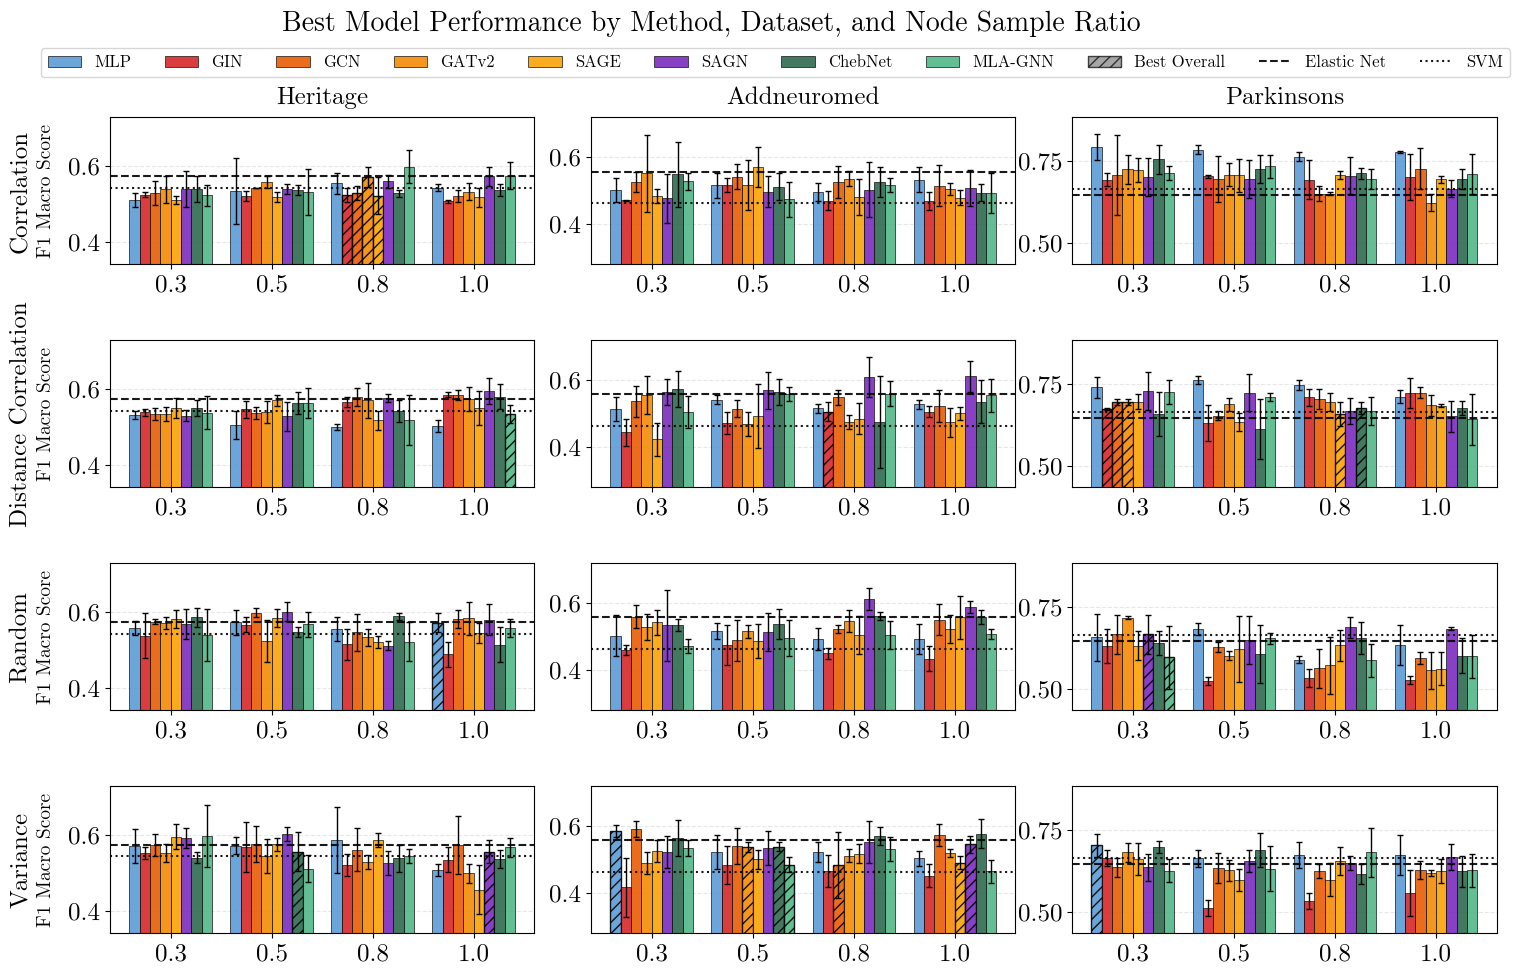


Data Summary:

correlation:
  motrpac:
    0.3:
      MLP: 0.5098 ± 0.0186
      GIN: 0.5245 ± 0.0072
      GCN: 0.5283 ± 0.0319
      GATv2: 0.5382 ± 0.0360
      SAGE: 0.5107 ± 0.0101
      SAGN: 0.5397 ± 0.0482
      ChebNet: 0.5401 ± 0.0342
      MLA-GNN: 0.5228 ± 0.0279
    0.5:
      MLP: 0.5339 ± 0.0859
      GIN: 0.5201 ± 0.0131
      GCN: 0.5410 ± 0.0000
      GATv2: 0.5579 ± 0.0159
      SAGE: 0.5179 ± 0.0128
      SAGN: 0.5389 ± 0.0129
      ChebNet: 0.5369 ± 0.0143
      MLA-GNN: 0.5317 ± 0.0604
    0.8:
      MLP: 0.5539 ± 0.0281
      GIN: 0.5231 ± 0.0188
      GCN: 0.5295 ± 0.0184
      GATv2: 0.5702 ± 0.0261
      SAGE: 0.5216 ± 0.0481
      SAGN: 0.5596 ± 0.0167
      ChebNet: 0.5277 ± 0.0100
      MLA-GNN: 0.5985 ± 0.0443
    1.0:
      MLP: 0.5425 ± 0.0093
      GIN: 0.5067 ± 0.0046
      GCN: 0.5218 ± 0.0160
      GATv2: 0.5323 ± 0.0218
      SAGE: 0.5176 ± 0.0245
      SAGN: 0.5726 ± 0.0252
      ChebNet: 0.5365 ± 0.0155
      MLA-GNN: 0.5747 ± 0.0347
  addneurome

In [10]:
# ------------------------------------------------------------------
# Plot: Best Model Performance by Method, Dataset, and Node Sample Ratio
# Selection: Best model by val/f1_macro for each method/dataset/ratio/model
# Display: Test F1 Macro (mean ± std) for the selected runs
# Highlight: Bars corresponding to "best overall" model selections are hatched
# ------------------------------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Column definitions
selection_metric_col = "summary.best_val/f1_macro"  # Use VAL F1 to select best runs
plot_metric_col = "summary.best_test/f1_macro"  # Plot TEST F1 for selected runs
plot_metric_std_col = f"{plot_metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
sampling_method_col = "dataset.loader.parameters.method"  # Rows: sampling methods
model_col = "model.model_name"  # Bars: models
node_sample_ratio_col = "dataset.loader.parameters.node_sample_ratio"

# Load and prepare data
df_plot2 = aggregated_df.copy()

# Filter for complete metrics (all 3 seeds must have val f1_macro and test f1_macro)
df_plot2 = filter_complete_metrics(df_plot2, [selection_metric_col, plot_metric_col])

# Decode serialized values for the grouping columns
for col in [data_name_col, sampling_method_col, model_col, node_sample_ratio_col]:
    if col in df_plot2.columns:
        df_plot2[col] = df_plot2[col].apply(_decode_val)

# Normalize model names to lowercase to avoid duplicates like "GATv4" vs "gatv4"
df_plot2[model_col] = df_plot2[model_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Normalize method names to lowercase as well
df_plot2[sampling_method_col] = df_plot2[sampling_method_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Ensure metrics are numeric
df_plot2[selection_metric_col] = pd.to_numeric(df_plot2[selection_metric_col], errors="coerce")
df_plot2[plot_metric_col] = pd.to_numeric(df_plot2[plot_metric_col], errors="coerce")
df_plot2[plot_metric_std_col] = pd.to_numeric(df_plot2[plot_metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot2 = df_plot2.dropna(subset=[data_name_col, sampling_method_col, model_col, node_sample_ratio_col, selection_metric_col, plot_metric_col])
df_plot2 = df_plot2[df_plot2[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique methods (columns), models (bars), datasets (rows), and ratios (groups)
all_methods = sorted(df_plot2[sampling_method_col].dropna().unique().tolist())
models_in_data = set(df_plot2[model_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order

# Round ratios to avoid floating point precision issues creating duplicates
df_plot2[node_sample_ratio_col] = df_plot2[node_sample_ratio_col].round(2)
all_ratios = sorted(df_plot2[node_sample_ratio_col].dropna().unique().tolist())

# Use CANONICAL_MODEL_ORDER defined in the color mapping cell
all_models = [m for m in CANONICAL_MODEL_ORDER if m in models_in_data]

# Use the shared color mapping created earlier
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")
model_colors = shared_model_colors_dict

# ------------------------------------------------------------------
# STEP 1: Compute "best overall" selections (matching the first plot)
# For each model-dataset, find the best run across ALL methods/ratios
# Store which (method, ratio) combination was selected
# ------------------------------------------------------------------
best_overall_selections = {}  # (model, dataset) -> (method, ratio)

for model in all_models:
    for dataset in datasets:
        # Get all runs for this model-dataset (across all methods and ratios)
        subset = df_plot2[
            (df_plot2[model_col] == model) &
            (df_plot2[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best run by VAL F1 Macro (same logic as the "Best Overall" plot)
            best_idx = subset[selection_metric_col].idxmax()
            best_method = subset.loc[best_idx, sampling_method_col]
            best_ratio = round(subset.loc[best_idx, node_sample_ratio_col], 2)
            best_overall_selections[(model, dataset)] = (best_method, best_ratio)

print("Best Overall Selections (matching the first plot):")
print("=" * 80)
for (model, dataset), (method, ratio) in sorted(best_overall_selections.items()):
    print(f"  {get_display_name(model):10s} + {dataset:12s} -> method={method}, ratio={ratio}")

# ------------------------------------------------------------------
# STEP 2: For each method-dataset-ratio-model, find best run by VAL F1
# ------------------------------------------------------------------
group_cols = [sampling_method_col, data_name_col, node_sample_ratio_col, model_col]
df_agg = df_plot2.loc[df_plot2.groupby(group_cols)[selection_metric_col].idxmax()].copy()

# Extract mean and std values for each method-dataset-ratio-model combination
plot_data = {}
for method in all_methods:
    plot_data[method] = {}
    for dataset in datasets:
        plot_data[method][dataset] = {}
        for ratio in all_ratios:
            plot_data[method][dataset][ratio] = {}
            for model in all_models:
                # Filter for this method-dataset-ratio-model combination
                subset = df_agg[
                    (df_agg[sampling_method_col] == method) &
                    (df_agg[data_name_col] == dataset) &
                    (df_agg[node_sample_ratio_col] == ratio) &
                    (df_agg[model_col] == model)
                ]
                
                if len(subset) >= 1:
                    # Get the row with best VAL F1 and extract TEST F1
                    best_idx = subset[selection_metric_col].idxmax()
                    plot_data[method][dataset][ratio][model] = {
                        'mean': subset.loc[best_idx, plot_metric_col],
                        'std': subset.loc[best_idx, plot_metric_std_col]
                    }
                else:
                    plot_data[method][dataset][ratio][model] = {'mean': np.nan, 'std': np.nan}

# Baseline F1 Macro scores for SVM and Elastic Net
baselines = {
    'parkinsons': {
        'elastic_net': 0.64518,
        'svm': 0.66422
    },
    'motrpac': {
        'elastic_net': 0.57419,
        'svm': 0.54287
    },
    'addneuromed': {
        'elastic_net': 0.55762,
        'svm': 0.46252
    }
}

# Create the subplot grid: 4 rows (methods) x 3 columns (datasets)
fig, axes = plt.subplots(len(all_methods), len(datasets), figsize=(16, 10))
fig.suptitle('Best Model Performance by Method, Dataset, and Node Sample Ratio', #\n(Selected by Val F1 Macro, Showing Test F1 Macro)', 
             fontsize=20, fontweight='bold', y=0.97)

# If only one method, axes will be 1D, so make it 2D
if len(all_methods) == 1:
    axes = axes.reshape(1, -1)
if len(datasets) == 1:
    axes = axes.reshape(-1, 1)

# First, calculate the min and max y-values for each dataset (column) across all methods
# This ensures all subplots in the same column have the same y-axis scale (dataset-specific)
dataset_min_vals = {}
dataset_max_vals = {}
for j, dataset in enumerate(datasets):
    min_val = float('inf')
    max_val = 0.3  # Start with minimum
    for i, method in enumerate(all_methods):
        method_data = plot_data[method][dataset]
        for ratio in all_ratios:
            for model in all_models:
                if model in method_data[ratio]:
                    mean_val = method_data[ratio][model]['mean']
                    std_val = method_data[ratio][model]['std']
                    if not np.isnan(mean_val):
                        # Consider mean - std for minimum (error bars can go below)
                        min_val = min(min_val, mean_val - (std_val if not np.isnan(std_val) else 0))
                        # Consider mean + std for maximum (error bars can go above)
                        max_val = max(max_val, mean_val + (std_val if not np.isnan(std_val) else 0))
    # Add 0.05 padding below min and above max
    if min_val == float('inf'):
        min_val = 0.3
    dataset_min_vals[dataset] = max(0.0, min_val - 0.05)
    dataset_max_vals[dataset] = max_val + 0.05

# Plot each subplot
# Each subplot shows: for each node_sample_ratio, bars for all models
bar_width = 0.9 / len(all_models)  # Width of each bar group (increased from 0.8)
group_width = 0.9  # Total width of each group
group_spacing = 1.1  # Spacing multiplier between ratio groups (1.0 = no extra spacing)

for i, method in enumerate(all_methods):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # Get data for this method-dataset combination
        method_data = plot_data[method][dataset]
        
        # Create positions for grouped bars with adjustable spacing
        x_groups = np.arange(len(all_ratios)) * group_spacing  # Positions for each ratio group
        x_positions = {}  # Store x positions for each model within each group
        
        # Calculate offset for each model to center the group
        for model_idx, model in enumerate(all_models):
            offset = (model_idx - (len(all_models) - 1) / 2) * bar_width
            x_positions[model] = x_groups + offset
        
        # Plot bars for each model, grouped by ratio
        # Track if we've already added labels for the legend (only need one per model)
        model_label_added = {m: False for m in all_models}
        best_overall_label_added = False
        
        for model in all_models:
            for ratio_idx, ratio in enumerate(all_ratios): 
                if model not in method_data[ratio]:
                    continue
                    
                mean_val = method_data[ratio][model]['mean']
                std_val = method_data[ratio][model]['std']
                
                if np.isnan(mean_val):
                    continue
                
                # Check if this bar corresponds to the "best overall" selection
                is_best_overall = False
                if (model, dataset) in best_overall_selections:
                    best_method, best_ratio = best_overall_selections[(model, dataset)]
                    if method == best_method and ratio == best_ratio:
                        is_best_overall = True
                
                # Determine hatching and label
                hatch_pattern = '///' if is_best_overall else None
                
                # Only add label once per model (for legend)
                if not model_label_added[model]:
                    label = get_display_name(model)
                    model_label_added[model] = True
                else:
                    label = None
                
                # Draw the bar
                bar = ax.bar(
                    x_positions[model][ratio_idx],
                    mean_val,
                    yerr=std_val,
                    width=bar_width,
                    capsize=2,
                    label=label,
                    color=model_colors[model],
                    edgecolor='black',
                    linewidth=1.0 if is_best_overall else 0.5,
                    alpha=0.9,
                    hatch=hatch_pattern,
                    error_kw={'elinewidth': 1, 'capthick': 1}
                )
        
        # Add baseline horizontal lines (SVM and Elastic Net)
        if dataset in baselines:
            for baseline_name, baseline_value in baselines[dataset].items():
                style = BASELINE_STYLES[baseline_name]
                ax.axhline(
                    y=baseline_value,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=1.5,
                    alpha=0.9,
                    label=style['label']
                )
        
        # Customize subplot
        ax.set_xticks(x_groups)
        ax.set_xticklabels(all_ratios, rotation=0, fontsize=18)
        ax.tick_params(axis='both', labelsize=18)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        # Set y-axis limits: same min/max for all subplots in the same column (dataset)
        ax.set_ylim(dataset_min_vals[dataset], dataset_max_vals[dataset])
        
        # Set title: dataset name on top, method name on left
        if i == 0:  # Top row: dataset names
            ax.set_title(get_dataset_display_name(dataset), fontsize=18, fontweight='bold', pad=10)
        if j == 0:  # Left column: method names (larger) and F1 Macro Score (smaller)
            # Use text annotations for different font sizes
            method_label = method.replace("_", " ").title()
            ax.text(-0.21, 0.5, method_label, transform=ax.transAxes, 
                   fontsize=18, fontweight='bold', ha='center', va='center', rotation=90)
            ax.text(-0.15, 0.5, 'F1 Macro Score', transform=ax.transAxes,
                   fontsize=14, fontweight='bold', ha='center', va='center', rotation=90)

# Collect handles and labels from the first subplot and deduplicate
handles, labels = axes[0, 0].get_legend_handles_labels()

# Deduplicate legend entries (keep order from CANONICAL_MODEL_ORDER for models, then baselines)
seen = set()
unique_handles, unique_labels = [], []
baseline_handles, baseline_labels = [], []

for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        # Separate model handles from baseline handles
        if l in ['Elastic Net', 'SVM']:
            baseline_handles.append(h)
            baseline_labels.append(l)
        else:
            unique_handles.append(h)
            unique_labels.append(l)

# Add a legend entry for the hatched bars (best overall selection)
from matplotlib.patches import Patch
best_overall_patch = Patch(facecolor='gray', edgecolor='black', hatch='///', 
                           label='Best Overall', alpha=0.7)

# Combine: models first, then best overall indicator, then baselines
all_handles = unique_handles + [best_overall_patch] + baseline_handles
all_labels = unique_labels + ['Best Overall'] + baseline_labels

# Add legend above the plots, next to the title
fig.legend(all_handles, all_labels, loc='upper center', bbox_to_anchor=(0.54, 0.94), 
           ncol=len(all_models) + 3, fontsize=12, frameon=True)

# Adjust layout - add left margin for y-axis labels
plt.tight_layout(rect=[0.06, 0, 1, 0.95])
fig.savefig('best_performance_by_method_dataset_ratio.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary
print("\nData Summary:")
print("=" * 80)
for method in all_methods:
    print(f"\n{method}:")
    for dataset in datasets:
        print(f"  {dataset}:")
        for ratio in all_ratios:
            print(f"    {ratio}:")
            for model in all_models:
                if model in plot_data[method][dataset][ratio]:
                    data = plot_data[method][dataset][ratio][model]
                    if not np.isnan(data['mean']):
                        print(f"      {get_display_name(model)}: {data['mean']:.4f} ± {data['std']:.4f}")
                    else:
                        print(f"      {get_display_name(model)}: No data")
                else:
                    print(f"      {get_display_name(model)}: No data")


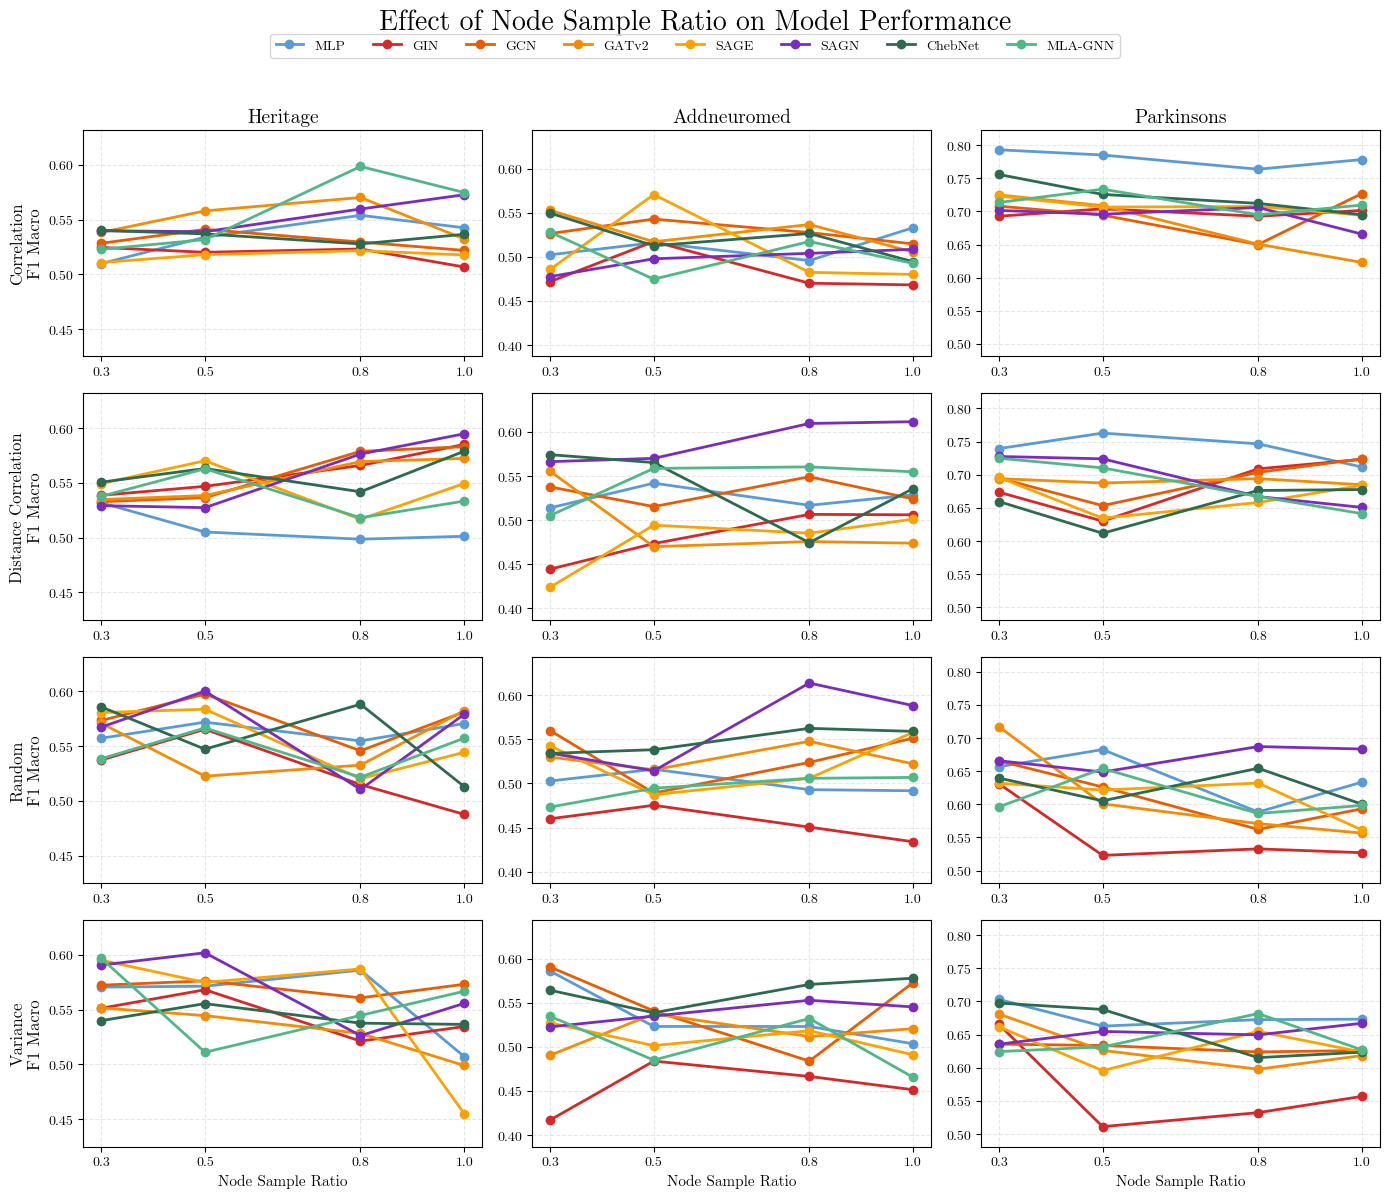

In [11]:
# ------------------------------------------------------------------
# Line Plot: Performance vs Node Sample Ratio (by Method)
# Shows trend clearly - does increasing ratio improve performance?
# One subplot per method-dataset combination
# ------------------------------------------------------------------
fig, axes = plt.subplots(len(all_methods), len(datasets), figsize=(14, 12))
fig.suptitle('Effect of Node Sample Ratio on Model Performance', 
             fontsize=20, fontweight='bold', y=0.995)

# Calculate y-limits per dataset column
dataset_ylims = {}
for dataset in datasets:
    all_vals = []
    for method in all_methods:
        for ratio in all_ratios:
            for model in all_models:
                val = plot_data[method][dataset][ratio][model]['mean']
                if not np.isnan(val):
                    all_vals.append(val)
    if all_vals:
        dataset_ylims[dataset] = (min(all_vals) - 0.03, max(all_vals) + 0.03)
    else:
        dataset_ylims[dataset] = (0.4, 0.9)

for i, method in enumerate(all_methods):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        for model in all_models:
            ratio_vals = [plot_data[method][dataset][ratio][model]['mean'] for ratio in all_ratios]
            ax.plot(all_ratios, ratio_vals, 'o-', 
                    color=shared_model_colors_dict[model], 
                    label=get_display_name(model), linewidth=2, markersize=6)
        
        ax.set_xticks(all_ratios)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_ylim(dataset_ylims[dataset])
        
        if i == 0:  # Top row: dataset names
            ax.set_title(get_dataset_display_name(dataset), fontsize=14, fontweight='bold')
        if j == 0:  # Left column: method names
            ax.set_ylabel(f'{method.replace("_", " ").title()}\nF1 Macro', fontsize=12, fontweight='bold')
        if i == len(all_methods) - 1:  # Bottom row
            ax.set_xlabel('Node Sample Ratio', fontsize=11)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
           ncol=8, fontsize=10, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('performance_vs_node_sample_ratio_lines.pdf', bbox_inches='tight', dpi=300)
plt.show()


/tmp/ipykernel_3388194/2295089169.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


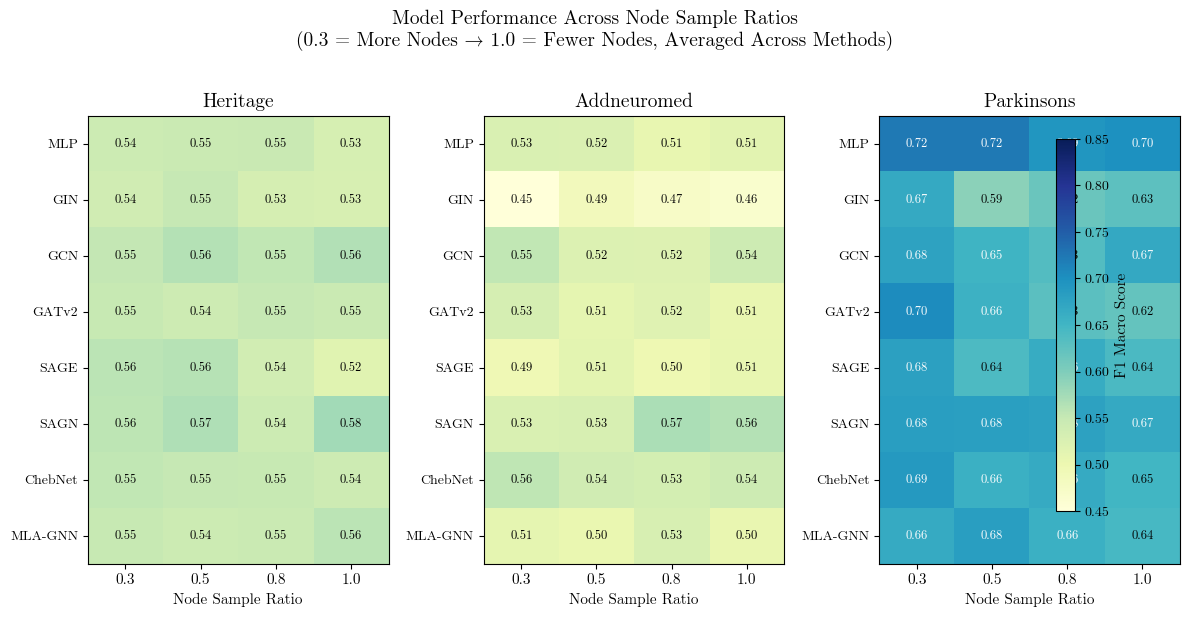

/tmp/ipykernel_3388194/2295089169.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.98, 0.97])


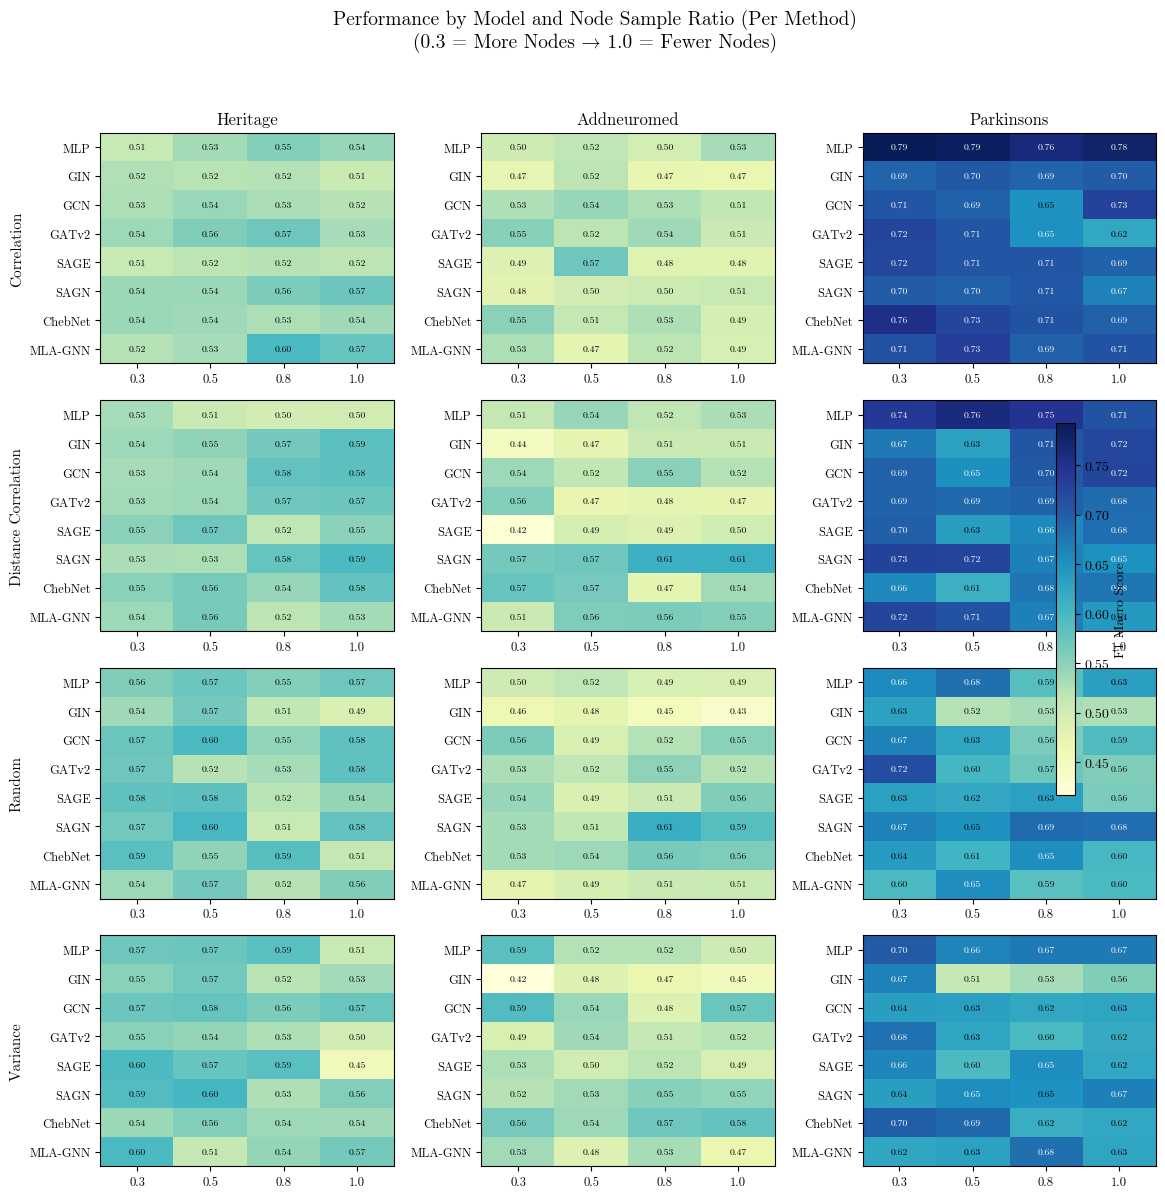

In [12]:
# ------------------------------------------------------------------
# Heatmap: Performance by Model and Node Sample Ratio
# Rows: models, Columns: ratios (0.3=more nodes, 1.0=fewer nodes)
# One heatmap per dataset (averaged across methods)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
fig.suptitle('Model Performance Across Node Sample Ratios\n(0.3 = More Nodes → 1.0 = Fewer Nodes, Averaged Across Methods)', 
             fontsize=14, fontweight='bold', y=1.02)

for j, dataset in enumerate(datasets):
    ax = axes[j]
    
    # Create matrix: models x ratios (averaged across methods)
    perf_matrix = np.zeros((len(all_models), len(all_ratios)))
    for i, model in enumerate(all_models):
        for k, ratio in enumerate(all_ratios):
            # Average across all methods
            method_perfs = [plot_data[method][dataset][ratio][model]['mean'] 
                          for method in all_methods 
                          if not np.isnan(plot_data[method][dataset][ratio][model]['mean'])]
            perf_matrix[i, k] = np.mean(method_perfs) if method_perfs else np.nan
    
    im = ax.imshow(perf_matrix, cmap='YlGnBu', aspect='auto', vmin=0.45, vmax=0.85)
    ax.set_xticks(range(len(all_ratios)))
    ax.set_xticklabels(all_ratios, fontsize=11)
    ax.set_yticks(range(len(all_models)))
    ax.set_yticklabels([get_display_name(m) for m in all_models], fontsize=10)
    ax.set_title(get_dataset_display_name(dataset), fontsize=14, fontweight='bold')
    ax.set_xlabel('Node Sample Ratio', fontsize=11)
    
    for i in range(len(all_models)):
        for k in range(len(all_ratios)):
            val = perf_matrix[i, k]
            if not np.isnan(val):
                color = 'white' if val > 0.65 else 'black'
                ax.text(k, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)

cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('F1 Macro Score', fontsize=11)
plt.tight_layout()
fig.savefig('heatmap_performance_averaged.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------------
# Also show per-method heatmaps
# ------------------------------------------------------------------
fig, axes = plt.subplots(len(all_methods), len(datasets), figsize=(12, 12))
fig.suptitle('Performance by Model and Node Sample Ratio (Per Method)\n(0.3 = More Nodes → 1.0 = Fewer Nodes)', 
             fontsize=14, fontweight='bold', y=0.995)

# Get global min/max for consistent color scale
all_perfs = []
for method in all_methods:
    for dataset in datasets:
        for ratio in all_ratios:
            for model in all_models:
                val = plot_data[method][dataset][ratio][model]['mean']
                if not np.isnan(val):
                    all_perfs.append(val)
vmin, vmax = min(all_perfs), max(all_perfs)

for i, method in enumerate(all_methods):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # Create matrix: models x ratios
        perf_matrix = np.zeros((len(all_models), len(all_ratios)))
        for m, model in enumerate(all_models):
            for r, ratio in enumerate(all_ratios):
                perf_matrix[m, r] = plot_data[method][dataset][ratio][model]['mean']
        
        im = ax.imshow(perf_matrix, cmap='YlGnBu', aspect='auto', vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(all_ratios)))
        ax.set_xticklabels(all_ratios, fontsize=9)
        ax.set_yticks(range(len(all_models)))
        ax.set_yticklabels([get_display_name(m) for m in all_models], fontsize=9)
        
        if i == 0:
            ax.set_title(get_dataset_display_name(dataset), fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{method.replace("_", " ").title()}', fontsize=11, fontweight='bold')
        
        for m in range(len(all_models)):
            for r in range(len(all_ratios)):
                val = perf_matrix[m, r]
                if not np.isnan(val):
                    color = 'white' if val > 0.65 else 'black'
                    ax.text(r, m, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('F1 Macro Score', fontsize=10)
plt.tight_layout(rect=[0, 0, 0.98, 0.97])
fig.savefig('heatmap_performance_per_method.pdf', bbox_inches='tight', dpi=300)
plt.show()


/tmp/ipykernel_3388194/3296969463.py:207: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) CMU Serif.
  fig.savefig('linear_regression_node_sample_ratio.pdf', bbox_inches='tight', dpi=300)
/home/lcornelis/anaconda3/envs/bgbench/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) CMU Serif.
  fig.canvas.print_figure(bytes_io, **kw)


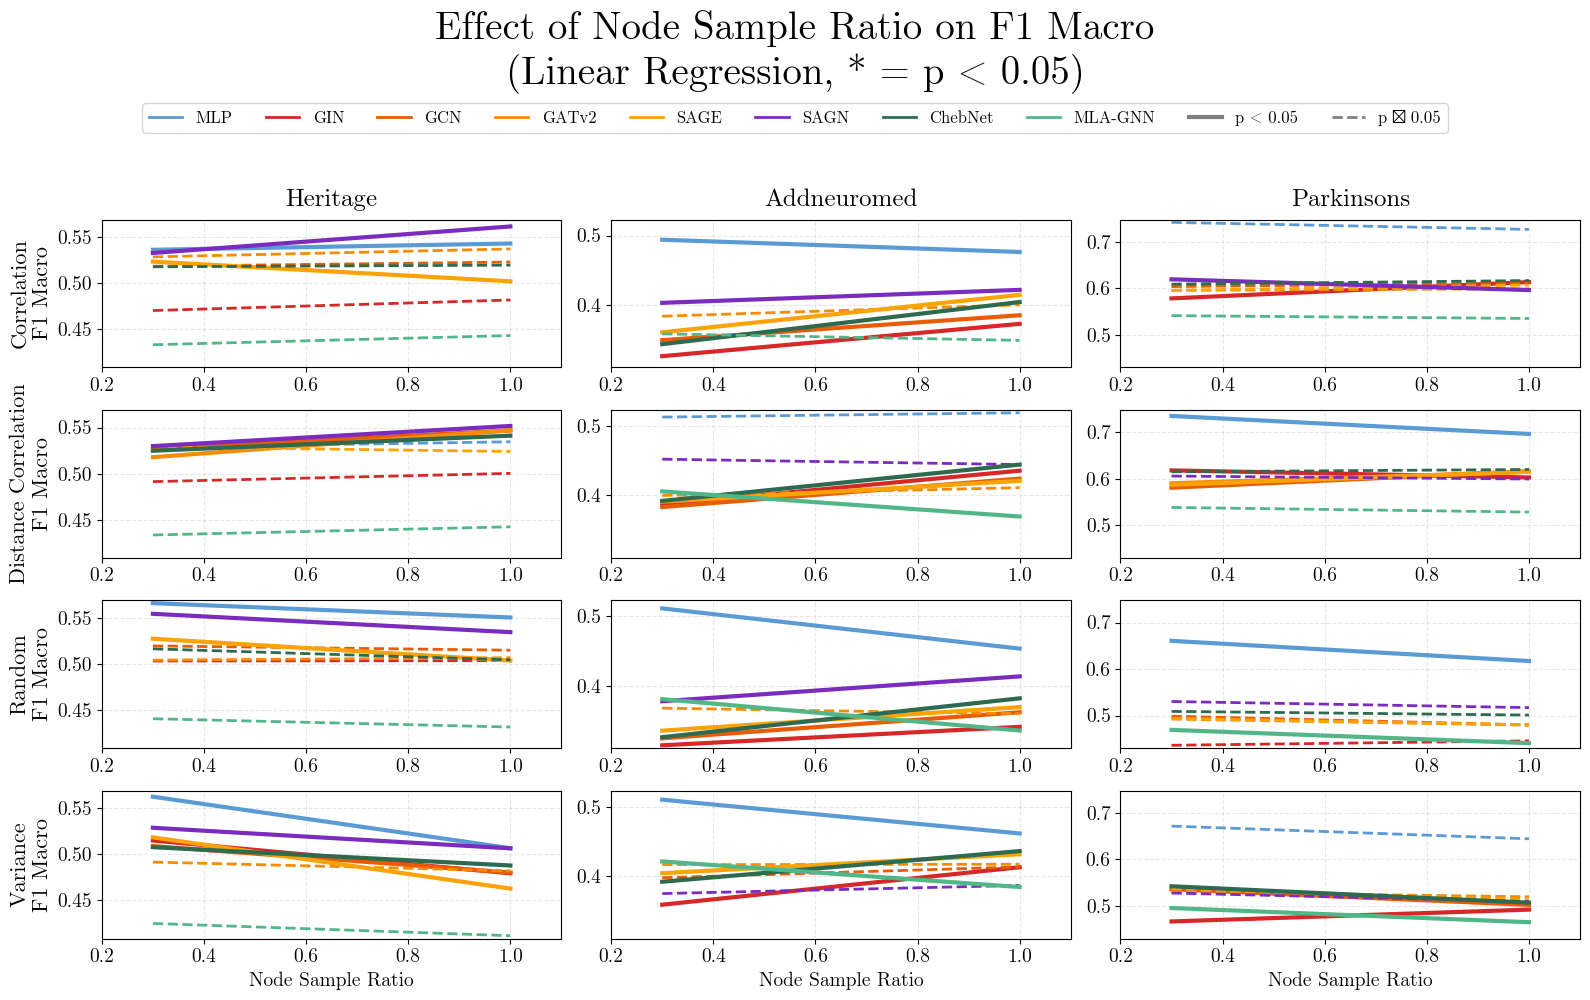


Summary: Statistically Significant Relationships (p < 0.05)
Dataset         Method                    Model           Slope       R²      p-value
----------------------------------------------------------------------------------------------------
motrpac         correlation               MLP           +0.0098↑   0.0288   1.8653e-02
motrpac         correlation               SAGE          -0.0306↓   0.0489   1.2317e-05
motrpac         correlation               SAGN          +0.0412↑   0.1191   6.9943e-23
motrpac         distance_correlation      GCN           +0.0285↑   0.0298   6.7434e-04
motrpac         distance_correlation      GATv2         +0.0417↑   0.0566   5.3048e-08
motrpac         distance_correlation      SAGN          +0.0313↑   0.1059   2.4930e-20
motrpac         distance_correlation      ChebNet       +0.0235↑   0.0203   5.1507e-03
motrpac         random                    MLP           -0.0223↓   0.0494   1.9938e-03
motrpac         random                    SAGE          

In [21]:
# ------------------------------------------------------------------
# Plot: Linear Regression of Node Sample Ratio vs F1 Macro
# Shows if there's a statistically significant relationship between
# node_sample_ratio and f1_macro for each model, dataset, and method
# ------------------------------------------------------------------
from scipy import stats

# Set font to CMU Serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Column definitions
metric_col = "summary.best_test/f1_macro"
metric_std_col = f"{metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "dataset.loader.parameters.method"
model_col = "model.model_name"
node_sample_ratio_col = "dataset.loader.parameters.node_sample_ratio"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_reg = aggregated_df.copy()

# Decode serialized values
for col in [data_name_col, method_col, model_col, node_sample_ratio_col]:
    if col in df_reg.columns:
        df_reg[col] = df_reg[col].apply(_decode_val)

# Normalize model names to lowercase to avoid duplicates
df_reg[model_col] = df_reg[model_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Normalize method names to lowercase as well
df_reg[method_col] = df_reg[method_col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Ensure metrics are numeric
df_reg[metric_col] = pd.to_numeric(df_reg[metric_col], errors="coerce")
df_reg[node_sample_ratio_col] = pd.to_numeric(df_reg[node_sample_ratio_col], errors="coerce")

# Filter to valid data and the three datasets
df_reg = df_reg.dropna(subset=[data_name_col, method_col, model_col, node_sample_ratio_col, metric_col])
df_reg = df_reg[df_reg[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get unique values
all_methods = sorted(df_reg[method_col].dropna().unique().tolist())
models_in_data = set(df_reg[model_col].dropna().unique().tolist())
all_models = [m for m in CANONICAL_MODEL_ORDER if m in models_in_data]
datasets = ["motrpac", "addneuromed", "parkinsons"]

# For each dataset-method-model combination, fit linear regression
regression_results = {}
for dataset in datasets:
    regression_results[dataset] = {}
    for method in all_methods:
        regression_results[dataset][method] = {}
        for model in all_models:
            # Get data for this combination
            subset = df_reg[
                (df_reg[data_name_col] == dataset) &
                (df_reg[method_col] == method) &
                (df_reg[model_col] == model)
            ]
            
            if len(subset) >= 2:  # Need at least 2 points for regression
                x = subset[node_sample_ratio_col].values
                y = subset[metric_col].values
                
                # Check if x values have variation (can't regress if all x are identical)
                if np.amax(x) == np.amin(x):
                    regression_results[dataset][method][model] = None
                    continue
                
                # Fit linear regression
                slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
                
                regression_results[dataset][method][model] = {
                    'slope': slope,
                    'intercept': intercept,
                    'r_squared': r_value**2,
                    'p_value': p_value,
                    'significant': p_value < 0.05,
                    'x': x,
                    'y': y
                }
            else:
                regression_results[dataset][method][model] = None

# Use the shared color mapping
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")

# Create the subplot grid: N rows (methods) x 3 columns (datasets)
fig, axes = plt.subplots(len(all_methods), len(datasets), figsize=(16, 10))
fig.suptitle('Effect of Node Sample Ratio on F1 Macro\n(Linear Regression, * = p < 0.05)', 
             fontsize=28, fontweight='bold', y=0.995)

# Handle 1D axes
if len(all_methods) == 1:
    axes = axes.reshape(1, -1)
if len(datasets) == 1:
    axes = axes.reshape(-1, 1)

# Calculate y-axis limits per column (dataset) - use tight limits based on regression lines only
dataset_ylims = {}
for dataset in datasets:
    # Get the y-values of the regression lines at x=0.3 and x=1.0 (the plotted range)
    line_y_vals = []
    for method in all_methods:
        for model in all_models:
            result = regression_results[dataset][method][model]
            if result is not None:
                slope = result['slope']
                intercept = result['intercept']
                # Get y-values at the endpoints of the regression line
                line_y_vals.append(slope * 0.3 + intercept)
                line_y_vals.append(slope * 1.0 + intercept)
    if line_y_vals:
        # Use the range of the regression lines, not the raw data points
        y_min, y_max = min(line_y_vals), max(line_y_vals)
        y_range = y_max - y_min
        # Small padding just to avoid clipping
        padding = y_range * 0.02
        dataset_ylims[dataset] = (y_min - padding, y_max + padding)
    else:
        dataset_ylims[dataset] = (0, 1)

# Plot each subplot (methods as rows, datasets as columns)
for i, method in enumerate(all_methods):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # Plot each model
        for model in all_models:
            result = regression_results[dataset][method][model]
            
            if result is not None:
                x = result['x']
                y = result['y']
                slope = result['slope']
                intercept = result['intercept']
                significant = result['significant']
                
                # Plot regression line (no scatter points for cleaner visualization)
                x_line = np.linspace(0.3, 1.0, 100)  # Full range of ratios
                y_line = slope * x_line + intercept
                
                # Add star to label if significant
                display_name = get_display_name(model)
                label = f"{display_name}*" if significant else display_name
                linestyle = '-' if significant else '--'
                linewidth = 3 if significant else 2
                
                ax.plot(x_line, y_line, color=shared_model_colors_dict[model], 
                       linestyle=linestyle, linewidth=linewidth, label=label)
        
        # Customize subplot
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(axis='both', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        ax.set_ylim(dataset_ylims[dataset])
        ax.set_xlim(0.2, 1.1)
        
        # Set titles
        if i == 0:  # Top row: dataset names
            ax.set_title(get_dataset_display_name(dataset), fontsize=18, fontweight='bold', pad=10)
        if j == 0:  # Left column: method names and y-label
            ax.set_ylabel(f'{method.replace("_", " ").title()}\nF1 Macro', fontsize=16, fontweight='bold')
        
        # X-axis label on bottom row only
        if i == len(all_methods) - 1:
            ax.set_xlabel('Node Sample Ratio', fontsize=14)

# Create consistent legend with all models (solid line = significant, dashed = not significant)
from matplotlib.lines import Line2D
legend_handles = []
legend_labels = []
for model in all_models:
    legend_handles.append(Line2D([0], [0], color=shared_model_colors_dict[model], 
                                  linestyle='-', linewidth=2))
    legend_labels.append(get_display_name(model))

# Add legend entries explaining line styles
legend_handles.append(Line2D([0], [0], color='gray', linestyle='-', linewidth=3))
legend_labels.append('p < 0.05')
legend_handles.append(Line2D([0], [0], color='gray', linestyle='--', linewidth=2))
legend_labels.append('p ≥ 0.05')

fig.legend(legend_handles, legend_labels, loc='upper center', 
           bbox_to_anchor=(0.5, 0.91), ncol=len(all_models) + 2, fontsize=12, frameon=True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig('linear_regression_node_sample_ratio.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary of significant relationships
print("\n" + "=" * 100)
print("Summary: Statistically Significant Relationships (p < 0.05)")
print("=" * 100)
print(f"{'Dataset':<15} {'Method':<25} {'Model':<10} {'Slope':>10} {'R²':>8} {'p-value':>12}")
print("-" * 100)

for dataset in datasets:
    for method in all_methods:
        for model in all_models:
            result = regression_results[dataset][method][model]
            if result is not None and result['significant']:
                direction = "↑" if result['slope'] > 0 else "↓"
                print(f"{dataset:<15} {method:<25} {get_display_name(model):<10} {result['slope']:>+10.4f}{direction} {result['r_squared']:>8.4f} {result['p_value']:>12.4e}")

print("\n" + "=" * 100)
print("All Regression Results")
print("=" * 100)
for dataset in datasets:
    print(f"\n{dataset.upper()}:")
    for method in all_methods:
        print(f"  {method}:")
        for model in all_models:
            result = regression_results[dataset][method][model]
            if result is not None:
                sig = "*" if result['significant'] else ""
                print(f"    {get_display_name(model)}: slope={result['slope']:+.4f}, R²={result['r_squared']:.4f}, p={result['p_value']:.4e}{sig}")
            else:
                print(f"    {get_display_name(model)}: Insufficient data")
